# DCASE 2026 Task 1 - BSD35k Train/Val + BSD10k Fold Test
## Baseline (HATR) - VSCode notebook (Windows + RTX 3060)

**This notebook keeps the original training settings, evaluation, and visualizations, but changes only the data split.**
- train/validation: `BSD35k-CS`
- test: original `BSD10k-v1.2` fold test split used by `DCASE2026_Task1_VSCode.ipynb`
- output: `dcase2026_task1_baseline/bsd35k_model_ouput/`

---


## 0. GPU 확인

In [1]:
import torch
print(torch.__version__)

2.5.1+cu121


In [2]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('⚠️  CUDA를 찾지 못했습니다. PyTorch CUDA 버전 설치를 확인하세요.')
    print('    pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121')

CUDA available: True
GPU: NVIDIA GeForce RTX 3060
VRAM: 8.6 GB


## 1. 패키지 설치

In [3]:
# 가상환경이 활성화된 상태에서 노트북을 실행하고 있는지 확인
import sys
print('Python 경로:', sys.executable)
# 출력에 .venv 경로가 포함되어 있어야 정상
# 예: C:\Users\yourname\DCASE_baseline\.venv\Scripts\python.exe

# 패키지 설치는 터미널에서 이미 완료했으므로 import 가능 여부만 확인
import torch, numpy, pandas, sklearn, yaml, matplotlib
print('모든 패키지 import 성공')

Python 경로: c:\Users\solok\Desktop\Dcase baseline\.venv\Scripts\python.exe
모든 패키지 import 성공


## 2. 경로 설정

**⚠️ `PROJECT_DIR`을 본인의 최상위 폴더 경로로 수정하세요.**

예시:
- `C:\Users\yourname\DCASE_baseline`
- `D:\projects\DCASE_baseline`

In [4]:
import os

# ↓↓↓ 여기만 본인 경로로 수정 ↓↓↓
PROJECT_DIR = r"C:\Users\solok\Desktop\Dcase baseline"  # 최상위 루트 (data/ 폴더가 있는 곳)
# ↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑

CODE_DIR = os.path.join(PROJECT_DIR, 'dcase2026_task1_baseline')  # git clone 위치
DATA_ROOT = os.path.join(PROJECT_DIR, 'data')                     # 데이터셋 위치

# 폴더 자동 생성
os.makedirs(CODE_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

print('최상위 루트  :', PROJECT_DIR)
print('코드 위치    :', CODE_DIR)
print('데이터 위치  :', DATA_ROOT)

최상위 루트  : C:\Users\solok\Desktop\Dcase baseline
코드 위치    : C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline
데이터 위치  : C:\Users\solok\Desktop\Dcase baseline\data


## 3. 베이스라인 코드 세팅

> **방법 A**: GitHub에서 클론 (권장)  
> **방법 B**: 이미 clone 해둔 경우 스킵

In [5]:
# 방법 A: GitHub 클론 (처음 세팅 시)
# 이미 clone 되어 있으면 이 셀은 스킵해도 됩니다
os.chdir(PROJECT_DIR)
!git clone https://github.com/MTG/dcase2026_task1_baseline.git

os.chdir(CODE_DIR)
print('코드 위치:', os.getcwd())
!dir

코드 위치: C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline


fatal: destination path 'dcase2026_task1_baseline' already exists and is not an empty directory.


 C ����̺��� �������� �̸��� �����ϴ�.
 ���� �Ϸ� ��ȣ: 5C92-C3CC

 C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline ���͸�

2026-05-29  ���� 03:34    <DIR>          .
2026-05-30  ���� 12:14    <DIR>          ..
2026-05-05  ���� 06:20                56 .gitignore
2026-05-29  ���� 03:34            26,393 attention_curve.png
2026-04-14  ���� 06:16             4,529 build_dataset.py
2026-05-29  ���� 01:48             1,081 config.yaml
2026-05-29  ���� 03:34           729,649 confusion_matrix_all_folds_normalized.png
2026-04-14  ���� 06:21    <DIR>          data
2026-05-05  ���� 08:46             2,181 dataset_utils.py
2026-05-29  ���� 01:48            15,248 evaluate.py
2026-05-05  ���� 03:08               317 losses.py
2026-04-14  ���� 06:16               568 main.py
2026-04-14  ���� 06:16             7,691 models.py
2026-04-29  ���� 11:56    <DIR>          model_output
2026-04-14  ���� 06:45             4,832 README.md
2026-04-14  ���� 06:16                82 requirements.txt
20

In [6]:
# 방법 B: 이미 clone된 경우 — 작업 디렉토리만 이동
os.chdir(CODE_DIR)
print('작업 디렉토리:', os.getcwd())

작업 디렉토리: C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline


## 4. config.yaml path setup

`DATA_ROOT` is set in the path cell above.  
This notebook uses BSD35k-CS for train/validation and BSD10k-v1.2 for fold-wise test splits.


In [7]:
ACTIVE_DATASET = 'BSD10k-v1.2'  # Keep original BSD10k fold test split basis
OUTPUT_ROOT = 'bsd35k_model_ouput'

# Convert Windows backslashes to forward slashes for YAML safety
data_root_str = DATA_ROOT.replace('\\', '/')

config_content = f"""# INPUT PATHS
active_dataset: {ACTIVE_DATASET}
datasets:
  BSD10k-v1.2:
    metadata_csv: "{data_root_str}/metadata/BSD10k_metadata.csv"
    audio_emb_folder: "{data_root_str}/features/clap_audio_embeddings"
    text_emb_folder: "{data_root_str}/features/clap_text_embeddings"
    class_names: "{data_root_str}/metadata/BST_description.csv"

  BSD35k-CS:
    metadata_csv: "{data_root_str}/metadata/BSD35k-CS_metadata.csv"
    audio_emb_folder: "{data_root_str}/features/BSD35k_clap_audio_embeddings"
    text_emb_folder: "{data_root_str}/features/BSD35k-CS_clap_text_embeddings"
    class_names: "{data_root_str}/metadata/BSD35k_BST_description.csv"

# OUTPUT PATHS
output_path: "data"
processed_dataset_csv: "processed_dataset.csv"
class_dict_json: "class_dict.json"
top_class_dict_json: "top_class_dict.json"
top_class_subclass_dict_json: "top_class_subclass_dict.json"
"""

with open('config.yaml', 'w') as f:
    f.write(config_content)

print('config.yaml saved')
print('Output root:', OUTPUT_ROOT)
with open('config.yaml') as f:
    print(f.read())



config.yaml saved
Output root: bsd35k_model_ouput
# INPUT PATHS
active_dataset: BSD10k-v1.2
datasets:
  BSD10k-v1.2:
    metadata_csv: "C:/Users/solok/Desktop/Dcase baseline/data/metadata/BSD10k_metadata.csv"
    audio_emb_folder: "C:/Users/solok/Desktop/Dcase baseline/data/features/clap_audio_embeddings"
    text_emb_folder: "C:/Users/solok/Desktop/Dcase baseline/data/features/clap_text_embeddings"
    class_names: "C:/Users/solok/Desktop/Dcase baseline/data/metadata/BST_description.csv"

  BSD35k-CS:
    metadata_csv: "C:/Users/solok/Desktop/Dcase baseline/data/metadata/BSD35k-CS_metadata.csv"
    audio_emb_folder: "C:/Users/solok/Desktop/Dcase baseline/data/features/BSD35k_clap_audio_embeddings"
    text_emb_folder: "C:/Users/solok/Desktop/Dcase baseline/data/features/BSD35k-CS_clap_text_embeddings"
    class_names: "C:/Users/solok/Desktop/Dcase baseline/data/metadata/BSD35k_BST_description.csv"

# OUTPUT PATHS
output_path: "data"
processed_dataset_csv: "processed_dataset.csv"
class

## 5. 데이터셋 경로 확인

실제 파일이 있는지 확인합니다.

In [8]:
import os

checks = [
    os.path.join(DATA_ROOT, 'metadata', 'BSD10k_metadata.csv'),
    os.path.join(DATA_ROOT, 'metadata', 'BSD35k-CS_metadata.csv'),
    os.path.join(DATA_ROOT, 'metadata', 'BST_description.csv'),
    os.path.join(DATA_ROOT, 'metadata', 'BSD35k_BST_description.csv'),
    os.path.join(DATA_ROOT, 'features', 'clap_audio_embeddings'),
    os.path.join(DATA_ROOT, 'features', 'clap_text_embeddings'),
    os.path.join(DATA_ROOT, 'features', 'BSD35k_clap_audio_embeddings'),
    os.path.join(DATA_ROOT, 'features', 'BSD35k-CS_clap_text_embeddings'),
]

all_ok = True
for path in checks:
    exists = os.path.exists(path)
    status = 'OK' if exists else 'MISSING'
    print(f'{status:7s}  {path}')
    if not exists:
        all_ok = False

if all_ok:
    print('\nAll required paths exist. Continue to the next cell.')
else:
    print('\nSome paths are missing. Check DATA_ROOT and the dataset folders.')


OK       C:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv
OK       C:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD35k-CS_metadata.csv
OK       C:\Users\solok\Desktop\Dcase baseline\data\metadata\BST_description.csv
OK       C:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD35k_BST_description.csv
OK       C:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings
OK       C:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings
OK       C:\Users\solok\Desktop\Dcase baseline\data\features\BSD35k_clap_audio_embeddings
OK       C:\Users\solok\Desktop\Dcase baseline\data\features\BSD35k-CS_clap_text_embeddings

All required paths exist. Continue to the next cell.


In [9]:
# metadata 폴더 파일 목록 확인
base = os.path.join(DATA_ROOT, 'metadata')
print('metadata 파일 목록:')
for f in os.listdir(base):
    print(f'  [{f}]')

metadata 파일 목록:
  [BSD10k_metadata.csv]
  [BSD35k-CS_metadata.csv]
  [BSD35k_BST_description.csv]
  [BST_description.csv]
  [BST_diagram.png]


## 6. train_test.py 버그 수정 패치

원본 코드에 `config.yaml`에 없는 키(`color_dict_path`)를 참조하는 버그가 있어 패치합니다.

In [10]:
# train_test.py 패치
with open('train_test.py', 'r') as f:
    code = f.read()

code = code.replace(
    'color_dict_path = get_subconfig("color_dict_path")\n',
    '# color_dict_path removed (not in config)\n'
)
code = code.replace(
    'top_color_dict_path = get_subconfig("top_color_dict_path")\n',
    '# top_color_dict_path removed (not in config)\n'
)

with open('train_test.py', 'w') as f:
    f.write(code)

print('train_test.py 패치 완료')

# evaluate.py 패치
with open('evaluate.py', 'r') as f:
    code = f.read()

code = code.replace(
    'color_dict_path = get_subconfig("color_dict_path")\n',
    '# color_dict_path removed\n'
)
code = code.replace(
    'top_color_dict_path = get_subconfig("top_color_dict_path")\n',
    '# top_color_dict_path removed\n'
)

with open('evaluate.py', 'w') as f:
    f.write(code)

print('evaluate.py 패치 완료')

train_test.py 패치 완료
evaluate.py 패치 완료


## 7. DataLoader num_workers 패치 (Windows 호환)

Windows에서 Jupyter 환경은 `if __name__ == '__main__'` 가드 없이 실행되므로  
`num_workers=0`으로 설정해야 멀티프로세싱 오류가 발생하지 않습니다.

In [11]:
for fname in ['train_test.py', 'evaluate.py']:
    with open(fname, 'r') as f:
        code = f.read()
    # Windows Jupyter 환경: num_workers=0 이 안전
    code = code.replace('num_workers=4', 'num_workers=0')
    code = code.replace('num_workers=2', 'num_workers=0')
    with open(fname, 'w') as f:
        f.write(code)

print('num_workers 패치 완료 (→ 0, Windows 호환)')

num_workers 패치 완료 (→ 0, Windows 호환)


## 8. Dataset build

Create processed CSV files for BSD35k-CS train/validation source and BSD10k-v1.2 original fold test source.


In [12]:
import os
import json
from pathlib import Path

import pandas as pd

OUTPUT_ROOT = 'bsd35k_model_ouput'
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

BSD10K_METADATA = Path(DATA_ROOT) / 'metadata' / 'BSD10k_metadata.csv'
BSD35K_METADATA = Path(DATA_ROOT) / 'metadata' / 'BSD35k-CS_metadata.csv'
CLASS_DESCRIPTION = Path(DATA_ROOT) / 'metadata' / 'BSD35k_BST_description.csv'

BSD10K_AUDIO_DIR = Path(DATA_ROOT) / 'features' / 'clap_audio_embeddings'
BSD10K_TEXT_DIR = Path(DATA_ROOT) / 'features' / 'clap_text_embeddings'
BSD35K_AUDIO_DIR = Path(DATA_ROOT) / 'features' / 'BSD35k_clap_audio_embeddings'
BSD35K_TEXT_DIR = Path(DATA_ROOT) / 'features' / 'BSD35k-CS_clap_text_embeddings'

BSD35K_PROCESSED_CSV = DATA_DIR / 'processed_dataset_bsd35k_trainval.csv'
BSD10K_TEST_SOURCE_CSV = DATA_DIR / 'processed_dataset_bsd10k_original_testfolds.csv'
CLASS_DICT_JSON = DATA_DIR / 'class_dict_bsd35k_train_bsd10k_test.json'
TOP_CLASS_DICT_JSON = DATA_DIR / 'top_class_dict_bsd35k_train_bsd10k_test.json'
TOP_CLASS_SUBCLASS_DICT_JSON = DATA_DIR / 'top_class_subclass_dict_bsd35k_train_bsd10k_test.json'


def load_leaf_class_order(description_path):
    desc = pd.read_csv(description_path)
    desc['class_key'] = desc['class_key'].astype(str)
    desc['class_idx'] = desc['class_idx'].astype(str)
    is_leaf = desc['class_key'].str.contains('-', regex=False)
    is_other = desc['class_key'].str.endswith('-other') | desc['class_idx'].str.endswith('99')
    ordered = desc[is_leaf & ~is_other].copy()
    ordered['class_idx_num'] = ordered['class_idx'].astype(int)
    return ordered.sort_values('class_idx_num')['class_key'].tolist()


class_order = load_leaf_class_order(CLASS_DESCRIPTION)
class_dict = {class_name: idx for idx, class_name in enumerate(class_order)}

top_class_order = []
for class_name in class_order:
    top = class_name.split('-')[0]
    if top not in top_class_order:
        top_class_order.append(top)
top_class_dict = {top: idx for idx, top in enumerate(top_class_order)}

top_class_subclass_dict = {
    top: {
        class_name: local_idx
        for local_idx, class_name in enumerate([c for c in class_order if c.startswith(f'{top}-')])
    }
    for top in top_class_order
}

with open(CLASS_DICT_JSON, 'w', encoding='utf-8') as f:
    json.dump(class_dict, f, indent=4, ensure_ascii=False)
with open(TOP_CLASS_DICT_JSON, 'w', encoding='utf-8') as f:
    json.dump(top_class_dict, f, indent=4, ensure_ascii=False)
with open(TOP_CLASS_SUBCLASS_DICT_JSON, 'w', encoding='utf-8') as f:
    json.dump(top_class_subclass_dict, f, indent=4, ensure_ascii=False)


def build_processed_dataset(metadata_csv, audio_dir, text_dir, dataset_name):
    df = pd.read_csv(metadata_csv)
    df['sound_id'] = df['sound_id'].astype(str).str.strip()
    df['class'] = df['class'].astype(str).str.strip()
    df = df[df['class'].isin(class_dict)].copy()
    df['top_class'] = df['class'].str.split('-').str[0]
    df['class_idx'] = df['class'].map(class_dict).astype(int)
    df['top_class_idx'] = df['top_class'].map(top_class_dict).astype(int)

    records = []
    missing_audio = 0
    missing_text = 0

    for _, row in df.iterrows():
        sound_id = row['sound_id']
        audio_path = Path(audio_dir) / f'{sound_id}.npy'
        text_path = Path(text_dir) / f'{sound_id}.npy'

        if not audio_path.is_file():
            missing_audio += 1
            continue
        if not text_path.is_file():
            missing_text += 1
            continue

        records.append({
            'index': sound_id,
            'audio_emb_filepath': str(audio_path.resolve()),
            'text_emb_filepath': str(text_path.resolve()),
            'top_class': row['top_class'],
            'top_class_idx': int(row['top_class_idx']),
            'class': row['class'],
            'class_idx': int(row['class_idx']),
        })

    out_df = pd.DataFrame(records)
    print(f'[{dataset_name}] metadata rows after class filter: {len(df):,}')
    print(f'[{dataset_name}] usable rows with audio+text embeddings: {len(out_df):,}')
    print(f'[{dataset_name}] missing audio: {missing_audio:,}, missing text: {missing_text:,}')
    print(f'[{dataset_name}] classes: {out_df["class"].nunique()}')
    return out_df


bsd35k_df = build_processed_dataset(
    BSD35K_METADATA,
    BSD35K_AUDIO_DIR,
    BSD35K_TEXT_DIR,
    'BSD35k-CS train/val source',
)
bsd10k_df = build_processed_dataset(
    BSD10K_METADATA,
    BSD10K_AUDIO_DIR,
    BSD10K_TEXT_DIR,
    'BSD10k-v1.2 original test-fold source',
)

bsd35k_df.to_csv(BSD35K_PROCESSED_CSV, index=False)
bsd10k_df.to_csv(BSD10K_TEST_SOURCE_CSV, index=False)

print('\nSaved:')
print(' ', BSD35K_PROCESSED_CSV)
print(' ', BSD10K_TEST_SOURCE_CSV)
print(' ', CLASS_DICT_JSON)
print(' ', TOP_CLASS_DICT_JSON)
print(' ', TOP_CLASS_SUBCLASS_DICT_JSON)



[BSD35k-CS train/val source] metadata rows after class filter: 31,464
[BSD35k-CS train/val source] usable rows with audio+text embeddings: 31,464
[BSD35k-CS train/val source] missing audio: 0, missing text: 0
[BSD35k-CS train/val source] classes: 23
[BSD10k-v1.2 original test-fold source] metadata rows after class filter: 10,956
[BSD10k-v1.2 original test-fold source] usable rows with audio+text embeddings: 10,956
[BSD10k-v1.2 original test-fold source] missing audio: 0, missing text: 0
[BSD10k-v1.2 original test-fold source] classes: 23

Saved:
  data\processed_dataset_bsd35k_trainval.csv
  data\processed_dataset_bsd10k_original_testfolds.csv
  data\class_dict_bsd35k_train_bsd10k_test.json
  data\top_class_dict_bsd35k_train_bsd10k_test.json
  data\top_class_subclass_dict_bsd35k_train_bsd10k_test.json


In [13]:
# Check build results
import pandas as pd

trainval_df = pd.read_csv('data/processed_dataset_bsd35k_trainval.csv')
test_source_df = pd.read_csv('data/processed_dataset_bsd10k_original_testfolds.csv')

print('[BSD35k train/val source]')
print(f'Total samples: {len(trainval_df)}')
print(f'Classes: {trainval_df["class"].nunique()}')
print(trainval_df['class'].value_counts().sort_index().to_string())

print('\n[BSD10k original fold test source]')
print(f'Total samples: {len(test_source_df)}')
print(f'Classes: {test_source_df["class"].nunique()}')
print(test_source_df['class'].value_counts().sort_index().to_string())



[BSD35k train/val source]
Total samples: 31464
Classes: 23
class
fx-a      730
fx-el    2000
fx-ex     839
fx-h     1423
fx-m     1542
fx-n      659
fx-o     4534
fx-v     1852
is-e     1360
is-k       43
is-p     2321
is-s      293
is-w       34
m-m      2044
m-si     1344
m-sp      964
sp-c       50
sp-p       69
sp-s      980
ss-i      383
ss-n     4831
ss-s      596
ss-u     2573

[BSD10k original fold test source]
Total samples: 10956
Classes: 23
class
fx-a      171
fx-el     208
fx-ex     298
fx-h      977
fx-m      281
fx-n      660
fx-o     1204
fx-v      204
is-e      308
is-k      359
is-p      608
is-s      528
is-w      565
m-m       320
m-si      711
m-sp      685
sp-c      175
sp-p      361
sp-s      807
ss-i      204
ss-n      391
ss-s      217
ss-u      714


## 9. 학습 실행

기본 설정: `both` (audio+text) + `audio` only 모드, 5-fold, 100 epoch  
RTX 3060 기준 약 **30~60분** 소요

In [14]:
# Full pipeline: BSD35k train/val + BSD10k original fold test + summary
import json
import os

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from torch.utils.data import DataLoader

from dataset_utils import HATRDataset
from evaluate import evaluate_model
from losses import CrossEntropyLoss
from models import BaseClassifier
from train_test import init_weights, make_serializable, train_model
from utils import build_class_to_topclass_mapping, set_seed

OUTPUT_ROOT = 'bsd35k_model_ouput'
TRAINVAL_CSV = 'data/processed_dataset_bsd35k_trainval.csv'
TEST_SOURCE_CSV = 'data/processed_dataset_bsd10k_original_testfolds.csv'
CLASS_DICT_JSON = 'data/class_dict_bsd35k_train_bsd10k_test.json'
TOP_CLASS_DICT_JSON = 'data/top_class_dict_bsd35k_train_bsd10k_test.json'

seed = set_seed()

with open(CLASS_DICT_JSON, encoding='utf-8') as f:
    class_dict = json.load(f)
with open(TOP_CLASS_DICT_JSON, encoding='utf-8') as f:
    top_class_dict = json.load(f)

modes = ['both', 'audio']
model_output = OUTPUT_ROOT

batch_size = 64
num_epochs = 100
learning_rate = 0.001
classification_weight = 1
scheduler_type = 'step'
patience = 5
early_stopping_factor = 3
k_folds = 5

bsd35k_df = pd.read_csv(TRAINVAL_CSV)
bsd10k_df = pd.read_csv(TEST_SOURCE_CSV)

bsd35k_labels = bsd35k_df['class_idx'].tolist()
bsd10k_labels = bsd10k_df['class_idx'].tolist()

bsd35k_skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
bsd10k_skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
bsd35k_splits = list(bsd35k_skf.split(np.zeros(len(bsd35k_labels)), bsd35k_labels))
bsd10k_splits = list(bsd10k_skf.split(np.zeros(len(bsd10k_labels)), bsd10k_labels))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Train/val source:', TRAINVAL_CSV, len(bsd35k_df))
print('Test source     :', TEST_SOURCE_CSV, len(bsd10k_df))
print('Output root     :', model_output)

for mode in modes:
    print(f'\n=== Running experiments: Train/Val=BSD35k-CS | Test=BSD10k-v1.2 | Mode={mode} ===')

    for fold in range(k_folds):
        print(f'\n==== Fold {fold} ====')

        bsd35k_trainval_idx, _ = bsd35k_splits[fold]
        _, bsd10k_test_idx = bsd10k_splits[fold]

        trainval_labels = [bsd35k_labels[i] for i in bsd35k_trainval_idx]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        train_idx_rel, val_idx_rel = next(sss.split(np.zeros(len(trainval_labels)), trainval_labels))
        train_idx = [bsd35k_trainval_idx[i] for i in train_idx_rel]
        val_idx = [bsd35k_trainval_idx[i] for i in val_idx_rel]

        train_df = bsd35k_df.iloc[train_idx].reset_index(drop=True)
        val_df = bsd35k_df.iloc[val_idx].reset_index(drop=True)
        test_df = bsd10k_df.iloc[bsd10k_test_idx].reset_index(drop=True)
        print(f'Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}')

        train_dataset = HATRDataset(train_df, aug=True, mask_pct=0.7)
        val_dataset = HATRDataset(val_df, aug=False)
        test_dataset = HATRDataset(test_df, aug=False)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

        emb_size_audio = 512 if mode in ['audio', 'both'] else 0
        emb_size_text = 512 if mode in ['text', 'both'] else 0

        hidden_size = 128
        dropout = 0.1

        model = BaseClassifier(
            hidden_size=hidden_size,
            num_classes=len(class_dict),
            emb_size_audio=emb_size_audio,
            emb_size_text=emb_size_text,
            dropout=dropout,
            use_batch_norm=True,
            mode=mode,
        ).to(device)

        classification_criterion = CrossEntropyLoss()

        output_dir = os.path.join(model_output, mode, f'fold_{fold}')
        os.makedirs(output_dir, exist_ok=True)
        model_path = os.path.join(output_dir, 'best_model.pth')

        init_weights(model)

        best_accuracy, history, trained_model = train_model(
            model,
            train_loader,
            val_loader,
            device,
            num_epochs=num_epochs,
            lr=learning_rate,
            classification_weight=classification_weight,
            classification_criterion=classification_criterion,
            output_dir=output_dir,
            scheduler_type=scheduler_type,
            patience=patience,
            early_stopping_factor=early_stopping_factor,
        )
        print(f'Best validation accuracy: {best_accuracy:.2f}%')

        splits_df = pd.concat([
            train_df[['index']].assign(split='train'),
            val_df[['index']].assign(split='val'),
            test_df[['index']].assign(split='test'),
        ])
        splits_df.to_csv(os.path.join(output_dir, 'splits.csv'), index=False)

        history['model_info'] = {
            'model_class': trained_model.__class__.__name__,
            'hidden_size': hidden_size,
            'num_classes': len(class_dict),
            'emb_size_audio': emb_size_audio,
            'emb_size_text': emb_size_text,
            'dropout': dropout,
            'use_batch_norm': True,
            'mode': mode,
            'num_folds': k_folds,
            'fold_id': fold,
            'batch_size': batch_size,
            'random_seed': seed,
        }

        history_path = os.path.join(output_dir, 'history.json')
        with open(history_path, 'w', encoding='utf-8') as f:
            json.dump(make_serializable(history), f, indent=2)

        class_to_top_class = build_class_to_topclass_mapping(class_dict, top_class_dict)

        metrics = evaluate_model(
            BaseClassifier,
            model_path,
            test_loader,
            device,
            class_to_top_class,
            output_dir=output_dir,
            fold_id=fold,
            class_dict=class_dict,
        )

        print('\n===== Fold Results =====')
        print(f"Final model accuracy: {metrics['accuracy']:.2f}%")
        print(f"Final model top-level accuracy: {metrics['top_accuracy']:.2f}%")
        print('========================')

print('All experiments done!')



Device: cuda
Train/val source: data/processed_dataset_bsd35k_trainval.csv 31464
Test source     : data/processed_dataset_bsd10k_original_testfolds.csv 10956
Output root     : bsd35k_model_ouput

=== Running experiments: Train/Val=BSD35k-CS | Test=BSD10k-v1.2 | Mode=both ===

==== Fold 0 ====
Train size: 20136, Val size: 5035, Test size: 2192
Epoch [1/100] - Val acc: 69.39%
  New best model saved
Epoch [2/100] - Val acc: 72.51%
  New best model saved
Epoch [3/100] - Val acc: 76.43%
  New best model saved
Epoch [4/100] - Val acc: 78.33%
  New best model saved
Epoch [5/100] - Val acc: 79.01%
  New best model saved
Epoch [6/100] - Val acc: 79.68%
  New best model saved
Epoch [7/100] - Val acc: 80.16%
  New best model saved
Epoch [8/100] - Val acc: 79.98%
Epoch [9/100] - Val acc: 81.57%
  New best model saved
Epoch [10/100] - Val acc: 80.95%
Epoch [11/100] - Val acc: 81.97%
  New best model saved
Epoch [12/100] - Val acc: 81.71%
Epoch [13/100] - Val acc: 81.97%
Epoch [14/100] - Val acc: 82.

C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold 0] Accuracy: 58.03%
[BaseClassifier | Fold 0] Top class accuracy: 74.41%
[BaseClassifier | Fold 0] Macro accuracy: 49.38%
[BaseClassifier | Fold 0] Macro top class accuracy: 68.69%
[BaseClassifier | Fold 0] Hierarchical accuracy: 59.03%
[BaseClassifier | Fold 0] Hierarchical precision: 63.33%
[BaseClassifier | Fold 0] Hierarchical recall: 56.62%
[BaseClassifier | Fold 0] Hierarchical F1: 56.23%

===== Fold Results =====
Final model accuracy: 58.03%
Final model top-level accuracy: 74.41%

==== Fold 1 ====
Train size: 20136, Val size: 5035, Test size: 2191
Epoch [1/100] - Val acc: 68.48%
  New best model saved
Epoch [2/100] - Val acc: 73.68%
  New best model saved
Epoch [3/100] - Val acc: 74.42%
  New best model saved
Epoch [4/100] - Val acc: 76.41%
  New best model saved
Epoch [5/100] - Val acc: 78.89%
  New best model saved
Epoch [6/100] - Val acc: 79.68%
  New best model saved
Epoch [7/100] - Val acc: 80.16%
  New best model saved
Epoch [8/100] - Val acc: 79.84%

C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold 1] Accuracy: 54.54%
[BaseClassifier | Fold 1] Top class accuracy: 70.47%
[BaseClassifier | Fold 1] Macro accuracy: 47.18%
[BaseClassifier | Fold 1] Macro top class accuracy: 65.22%
[BaseClassifier | Fold 1] Hierarchical accuracy: 56.20%
[BaseClassifier | Fold 1] Hierarchical precision: 57.94%
[BaseClassifier | Fold 1] Hierarchical recall: 58.17%
[BaseClassifier | Fold 1] Hierarchical F1: 56.06%

===== Fold Results =====
Final model accuracy: 54.54%
Final model top-level accuracy: 70.47%

==== Fold 2 ====
Train size: 20136, Val size: 5035, Test size: 2191
Epoch [1/100] - Val acc: 67.03%
  New best model saved
Epoch [2/100] - Val acc: 73.01%
  New best model saved
Epoch [3/100] - Val acc: 71.14%
Epoch [4/100] - Val acc: 78.15%
  New best model saved
Epoch [5/100] - Val acc: 77.12%
Epoch [6/100] - Val acc: 78.53%
  New best model saved
Epoch [7/100] - Val acc: 80.02%
  New best model saved
Epoch [8/100] - Val acc: 78.89%
Epoch [9/100] - Val acc: 80.62%
  New best mo

...

[BaseClassifier | Fold 2] Accuracy: 51.85%
[BaseClassifier | Fold 2] Top class accuracy: 69.15%
[BaseClassifier | Fold 2] Macro accuracy: 42.35%
[BaseClassifier | Fold 2] Macro top class accuracy: 63.57%
[BaseClassifier | Fold 2] Hierarchical accuracy: 52.96%
[BaseClassifier | Fold 2] Hierarchical precision: 56.81%
[BaseClassifier | Fold 2] Hierarchical recall: 50.31%
[BaseClassifier | Fold 2] Hierarchical F1: 50.42%

===== Fold Results =====
Final model accuracy: 51.85%
Final model top-level accuracy: 69.15%

==== Fold 3 ====
Train size: 20136, Val size: 5035, Test size: 2191
Epoch [1/100] - Val acc: 57.16%
  New best model saved
Epoch [2/100] - Val acc: 62.72%
  New best model saved
Epoch [3/100] - Val acc: 64.11%
  New best model saved
Epoch [4/100] - Val acc: 65.42%
  New best model saved
Epoch [5/100] - Val acc: 67.03%
  New best model saved
Epoch [6/100] - Val acc: 67.43%
  New best model saved
Epoch [7/100] - Val acc: 68.74%
  New best model saved
Epoch [8/100] - Val acc: 68.86%

C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold 3] Accuracy: 51.35%
[BaseClassifier | Fold 3] Top class accuracy: 68.23%
[BaseClassifier | Fold 3] Macro accuracy: 42.84%
[BaseClassifier | Fold 3] Macro top class accuracy: 62.89%
[BaseClassifier | Fold 3] Hierarchical accuracy: 52.86%
[BaseClassifier | Fold 3] Hierarchical precision: 55.89%
[BaseClassifier | Fold 3] Hierarchical recall: 50.35%
[BaseClassifier | Fold 3] Hierarchical F1: 50.16%

===== Fold Results =====
Final model accuracy: 51.35%
Final model top-level accuracy: 68.23%

==== Fold 4 ====
Train size: 20137, Val size: 5035, Test size: 2191
Epoch [1/100] - Val acc: 56.72%
  New best model saved
Epoch [2/100] - Val acc: 62.94%
  New best model saved
Epoch [3/100] - Val acc: 64.49%
  New best model saved
Epoch [4/100] - Val acc: 66.12%
  New best model saved
Epoch [5/100] - Val acc: 65.92%
Epoch [6/100] - Val acc: 68.42%
  New best model saved
Epoch [7/100] - Val acc: 66.77%
Epoch [8/100] - Val acc: 69.79%
  New best model saved
Epoch [9/100] - Val ac

C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold 4] Accuracy: 48.20%
[BaseClassifier | Fold 4] Top class accuracy: 67.46%
[BaseClassifier | Fold 4] Macro accuracy: 39.80%
[BaseClassifier | Fold 4] Macro top class accuracy: 63.03%
[BaseClassifier | Fold 4] Hierarchical accuracy: 51.42%
[BaseClassifier | Fold 4] Hierarchical precision: 53.46%
[BaseClassifier | Fold 4] Hierarchical recall: 48.51%
[BaseClassifier | Fold 4] Hierarchical F1: 48.20%

===== Fold Results =====
Final model accuracy: 48.20%
Final model top-level accuracy: 67.46%
All experiments done!


## 10. 결과 요약

In [15]:
from summarize_results import summarize_metrics

OUTPUT_ROOT = 'bsd35k_model_ouput'
summarize_metrics(root_dir=OUTPUT_ROOT, output_file='summary_metrics.txt')

with open(f'{OUTPUT_ROOT}/summary_metrics.txt') as f:
    print(f.read())


Summary written to bsd35k_model_ouput\summary_metrics.txt
=== Experiment Summary ===

audio/evaluation
  accuracy    : 50.56% ± 1.35%
  hierarchical_accuracy: 52.20% ± 0.95%
  hierarchical_f1: 49.15% ± 1.29%
  hierarchical_precision: 54.34% ± 1.86%
  hierarchical_recall: 49.53% ± 0.94%
  macro_accuracy: 41.50% ± 1.09%
  macro_top_accuracy: 62.91% ± 1.27%
  top_accuracy: 68.21% ± 1.18%
  runs        : 5

both/evaluation
  accuracy    : 56.20% ± 1.47%
  hierarchical_accuracy: 57.87% ± 1.10%
  hierarchical_f1: 55.63% ± 0.53%
  hierarchical_precision: 59.82% ± 1.93%
  hierarchical_recall: 56.64% ± 0.95%
  macro_accuracy: 48.30% ± 0.87%
  macro_top_accuracy: 67.44% ± 1.36%
  top_accuracy: 72.26% ± 1.53%
  runs        : 5




---
## 11. [선택] 빠른 단일 fold 테스트

전체 5-fold 실행 전에 1개 fold만 빠르게 돌려서 동작을 확인할 때 사용  
RTX 3060 기준 epoch=10 → 약 **2~5분**

In [16]:
import sys, os, json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

# Check current working directory; it should be CODE_DIR
print('Current path:', os.getcwd())

from utils import set_seed, build_class_to_topclass_mapping
from models import BaseClassifier
from losses import CrossEntropyLoss
from dataset_utils import HATRDataset
from evaluate import evaluate_model
from train_test import train_model, init_weights

# ---- Settings ----
FOLD_ID    = 0         # Fold to test
MODE       = 'both'    # 'both' | 'audio' | 'text'
NUM_EPOCHS = 10        # Quick test epochs; full run uses 100
BATCH_SIZE = 64        # Use 32 if CUDA runs out of memory
HIDDEN     = 128
DROPOUT    = 0.1
K_FOLDS    = 5
OUTPUT_ROOT = 'bsd35k_model_ouput'
# --------------

seed = set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

with open('data/class_dict_bsd35k_train_bsd10k_test.json', encoding='utf-8') as f:
    class_dict = json.load(f)
with open('data/top_class_dict_bsd35k_train_bsd10k_test.json', encoding='utf-8') as f:
    top_class_dict = json.load(f)

bsd35k_df = pd.read_csv('data/processed_dataset_bsd35k_trainval.csv')
bsd10k_df = pd.read_csv('data/processed_dataset_bsd10k_original_testfolds.csv')

bsd35k_labels = bsd35k_df['class_idx'].tolist()
bsd10k_labels = bsd10k_df['class_idx'].tolist()

bsd35k_skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=seed)
bsd10k_skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=seed)
bsd35k_splits = list(bsd35k_skf.split(np.zeros(len(bsd35k_labels)), bsd35k_labels))
bsd10k_splits = list(bsd10k_skf.split(np.zeros(len(bsd10k_labels)), bsd10k_labels))

bsd35k_trainval_idx, _ = bsd35k_splits[FOLD_ID]
_, bsd10k_test_idx = bsd10k_splits[FOLD_ID]

trainval_labels = [bsd35k_labels[i] for i in bsd35k_trainval_idx]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
train_idx_rel, val_idx_rel = next(sss.split(np.zeros(len(trainval_labels)), trainval_labels))
train_idx = [bsd35k_trainval_idx[i] for i in train_idx_rel]
val_idx = [bsd35k_trainval_idx[i] for i in val_idx_rel]

train_df = bsd35k_df.iloc[train_idx].reset_index(drop=True)
val_df = bsd35k_df.iloc[val_idx].reset_index(drop=True)
test_df = bsd10k_df.iloc[bsd10k_test_idx].reset_index(drop=True)
print(f'Fold {FOLD_ID}: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')

# Windows: num_workers=0 is required
train_loader = DataLoader(HATRDataset(train_df, aug=True,  mask_pct=0.7), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=0, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(HATRDataset(val_df,   aug=False),                batch_size=BATCH_SIZE, shuffle=False,                  num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(HATRDataset(test_df,  aug=False),                batch_size=BATCH_SIZE, shuffle=False,                  num_workers=0, pin_memory=torch.cuda.is_available())

emb_size_audio = 512 if MODE in ['audio', 'both'] else 0
emb_size_text  = 512 if MODE in ['text',  'both'] else 0

model = BaseClassifier(
    hidden_size=HIDDEN,
    num_classes=len(class_dict),
    emb_size_audio=emb_size_audio,
    emb_size_text=emb_size_text,
    dropout=DROPOUT,
    use_batch_norm=True,
    mode=MODE
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model params: {total_params:,}')

init_weights(model)

out_dir = f'{OUTPUT_ROOT}/{MODE}/fold_{FOLD_ID}'
os.makedirs(out_dir, exist_ok=True)

best_acc, history, trained_model = train_model(
    model, train_loader, val_loader, device,
    num_epochs=NUM_EPOCHS,
    lr=0.001,
    classification_criterion=CrossEntropyLoss(),
    output_dir=out_dir,
    scheduler_type='step',
    patience=5,
    early_stopping_factor=3
)

print(f'\nBest val accuracy: {best_acc:.2f}%')

metrics = evaluate_model(
    BaseClassifier,
    os.path.join(out_dir, 'best_model.pth'),
    test_loader, device,
    class_to_topclass=build_class_to_topclass_mapping(class_dict, top_class_dict),
    output_dir=out_dir,
    fold_id=FOLD_ID,
    class_dict=class_dict
)

print('\n===== Final Results =====')
for k, v in metrics.items():
    print(f'  {k}: {v:.2f}%')




Current path: C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline
Device: cuda
Fold 0: train=20136, val=5035, test=2192
Model params: 7,319,513
Epoch [1/10] - Val acc: 69.39%
  New best model saved
Epoch [2/10] - Val acc: 72.51%
  New best model saved
Epoch [3/10] - Val acc: 76.43%
  New best model saved
Epoch [4/10] - Val acc: 78.33%
  New best model saved
Epoch [5/10] - Val acc: 79.01%
  New best model saved
Epoch [6/10] - Val acc: 79.68%
  New best model saved
Epoch [7/10] - Val acc: 80.16%
  New best model saved
Epoch [8/10] - Val acc: 79.98%
Epoch [9/10] - Val acc: 81.57%
  New best model saved
Epoch [10/10] - Val acc: 80.95%

Best val accuracy: 81.57%


C:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold 0] Accuracy: 52.78%
[BaseClassifier | Fold 0] Top class accuracy: 71.12%
[BaseClassifier | Fold 0] Macro accuracy: 43.18%
[BaseClassifier | Fold 0] Macro top class accuracy: 66.07%
[BaseClassifier | Fold 0] Hierarchical accuracy: 54.63%
[BaseClassifier | Fold 0] Hierarchical precision: 55.21%
[BaseClassifier | Fold 0] Hierarchical recall: 56.00%
[BaseClassifier | Fold 0] Hierarchical F1: 51.85%

===== Final Results =====
  accuracy: 52.78%
  top_accuracy: 71.12%
  macro_accuracy: 43.18%
  macro_top_accuracy: 66.07%
  hierarchical_accuracy: 54.63%
  hierarchical_precision: 55.21%
  hierarchical_recall: 56.00%
  hierarchical_f1: 51.85%


## 12. 학습 곡선 시각화

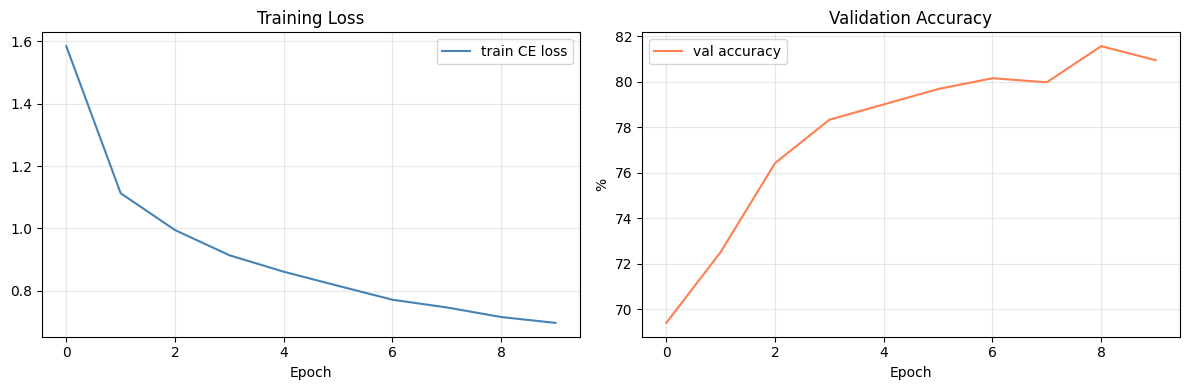

bsd35k_model_ouput\training_curve.png saved


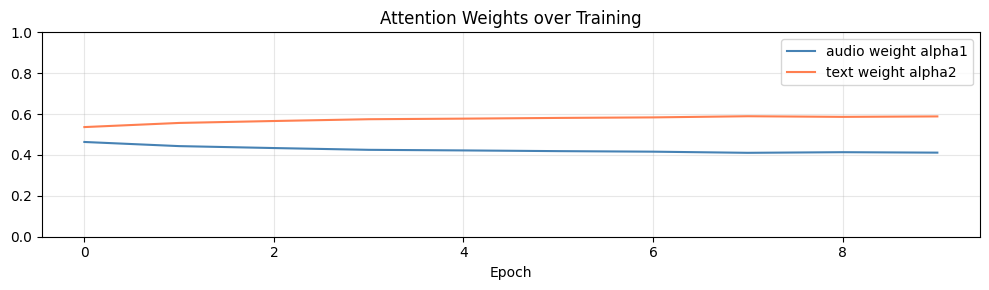

In [17]:
import matplotlib.pyplot as plt
import json
import os

OUTPUT_ROOT = 'bsd35k_model_ouput'
plot_mode = MODE if 'MODE' in globals() else 'both'

with open(f'{OUTPUT_ROOT}/{plot_mode}/fold_0/history.json') as f:
    h = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(h.get('train_cls_loss', []), label='train CE loss', color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(h.get('val_accuracy', []), label='val accuracy', color='coral')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'training_curve.png'), dpi=150)
plt.show()
print(os.path.join(OUTPUT_ROOT, 'training_curve.png'), 'saved')

# Attention weight change when mode='both'
if 'attention_audio' in h:
    fig2, ax2 = plt.subplots(figsize=(10, 3))
    audio_attn = [x if isinstance(x, float) else x[0] for x in h['attention_audio']]
    text_attn  = [x if isinstance(x, float) else x[0] for x in h['attention_text']]
    ax2.plot(audio_attn, label='audio weight alpha1', color='steelblue')
    ax2.plot(text_attn,  label='text weight alpha2',  color='coral')
    ax2.set_title('Attention Weights over Training')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_ROOT, 'attention_curve.png'), dpi=150)
    plt.show()



## 13. 결과 로컬 백업

In [18]:
import shutil

OUTPUT_ROOT = 'bsd35k_model_ouput'

# Back up bsd35k_model_ouput under PROJECT_DIR
backup_path = os.path.join(PROJECT_DIR, 'bsd35k_model_ouput_backup')
if os.path.exists(backup_path):
    shutil.rmtree(backup_path)
shutil.copytree(OUTPUT_ROOT, backup_path)
print(f'Backup complete: {backup_path}')



Backup complete: C:\Users\solok\Desktop\Dcase baseline\bsd35k_model_ouput_backup


---
## 알려진 이슈 & 해결법

| 증상 | 원인 | 해결 |
|------|------|------|
| `KeyError: 'color_dict_path'` | config.yaml에 없는 키 참조 | 셀 6 패치 적용 |
| `RuntimeError: DataLoader worker` 오류 | Windows 멀티프로세싱 제한 | 셀 7 패치 (num_workers=0) |
| `CUDA out of memory` | batch_size 너무 큼 | `BATCH_SIZE=32` 로 줄이기 |
| `CUDA available: False` | PyTorch CPU 버전 설치됨 | `pip install torch ... --index-url https://download.pytorch.org/whl/cu121` |
| `Missing audio embedding` 많이 출력 | 임베딩 경로 불일치 | `DATA_ROOT` 경로 재확인, 셀 4 재실행 |
| `ModuleNotFoundError` | 작업 디렉토리가 CODE_DIR이 아님 | 셀 3-B 재실행 후 `os.chdir(CODE_DIR)` |

---
*DCASE 2026 Task 1 — Good luck!*

## 14. All-fold normalized Confusion Matrix


Mode: both
Folds: fold_0, fold_1, fold_2, fold_3, fold_4
Overall accuracy across folds: 55.16% +/- 1.65%

Per-class recall, diagonal of normalized confusion matrix:
      m-sp: 60.88% +/- 3.47%
      m-si: 59.35% +/- 6.86%
       m-m: 57.19% +/- 7.17%
      is-p: 52.62% +/- 3.37%
      is-s: 69.33% +/- 4.97%
      is-w: 25.49% +/- 23.29%
      is-k: 18.61% +/- 22.90%
      is-e: 34.75% +/- 4.27%
      sp-s: 92.82% +/- 1.38%
      sp-c: 16.57% +/- 12.96%
      sp-p: 15.20% +/- 12.28%
      fx-o: 80.06% +/- 4.32%
      fx-v: 45.13% +/- 8.46%
      fx-m: 42.69% +/- 5.26%
      fx-h: 71.24% +/- 3.34%
      fx-a: 44.99% +/- 10.25%
      fx-n: 26.82% +/- 4.66%
     fx-ex: 5.37% +/- 1.98%
     fx-el: 49.07% +/- 4.77%
      ss-n: 79.53% +/- 4.08%
      ss-i: 33.83% +/- 13.49%
      ss-u: 68.63% +/- 5.48%
      ss-s: 32.33% +/- 17.03%


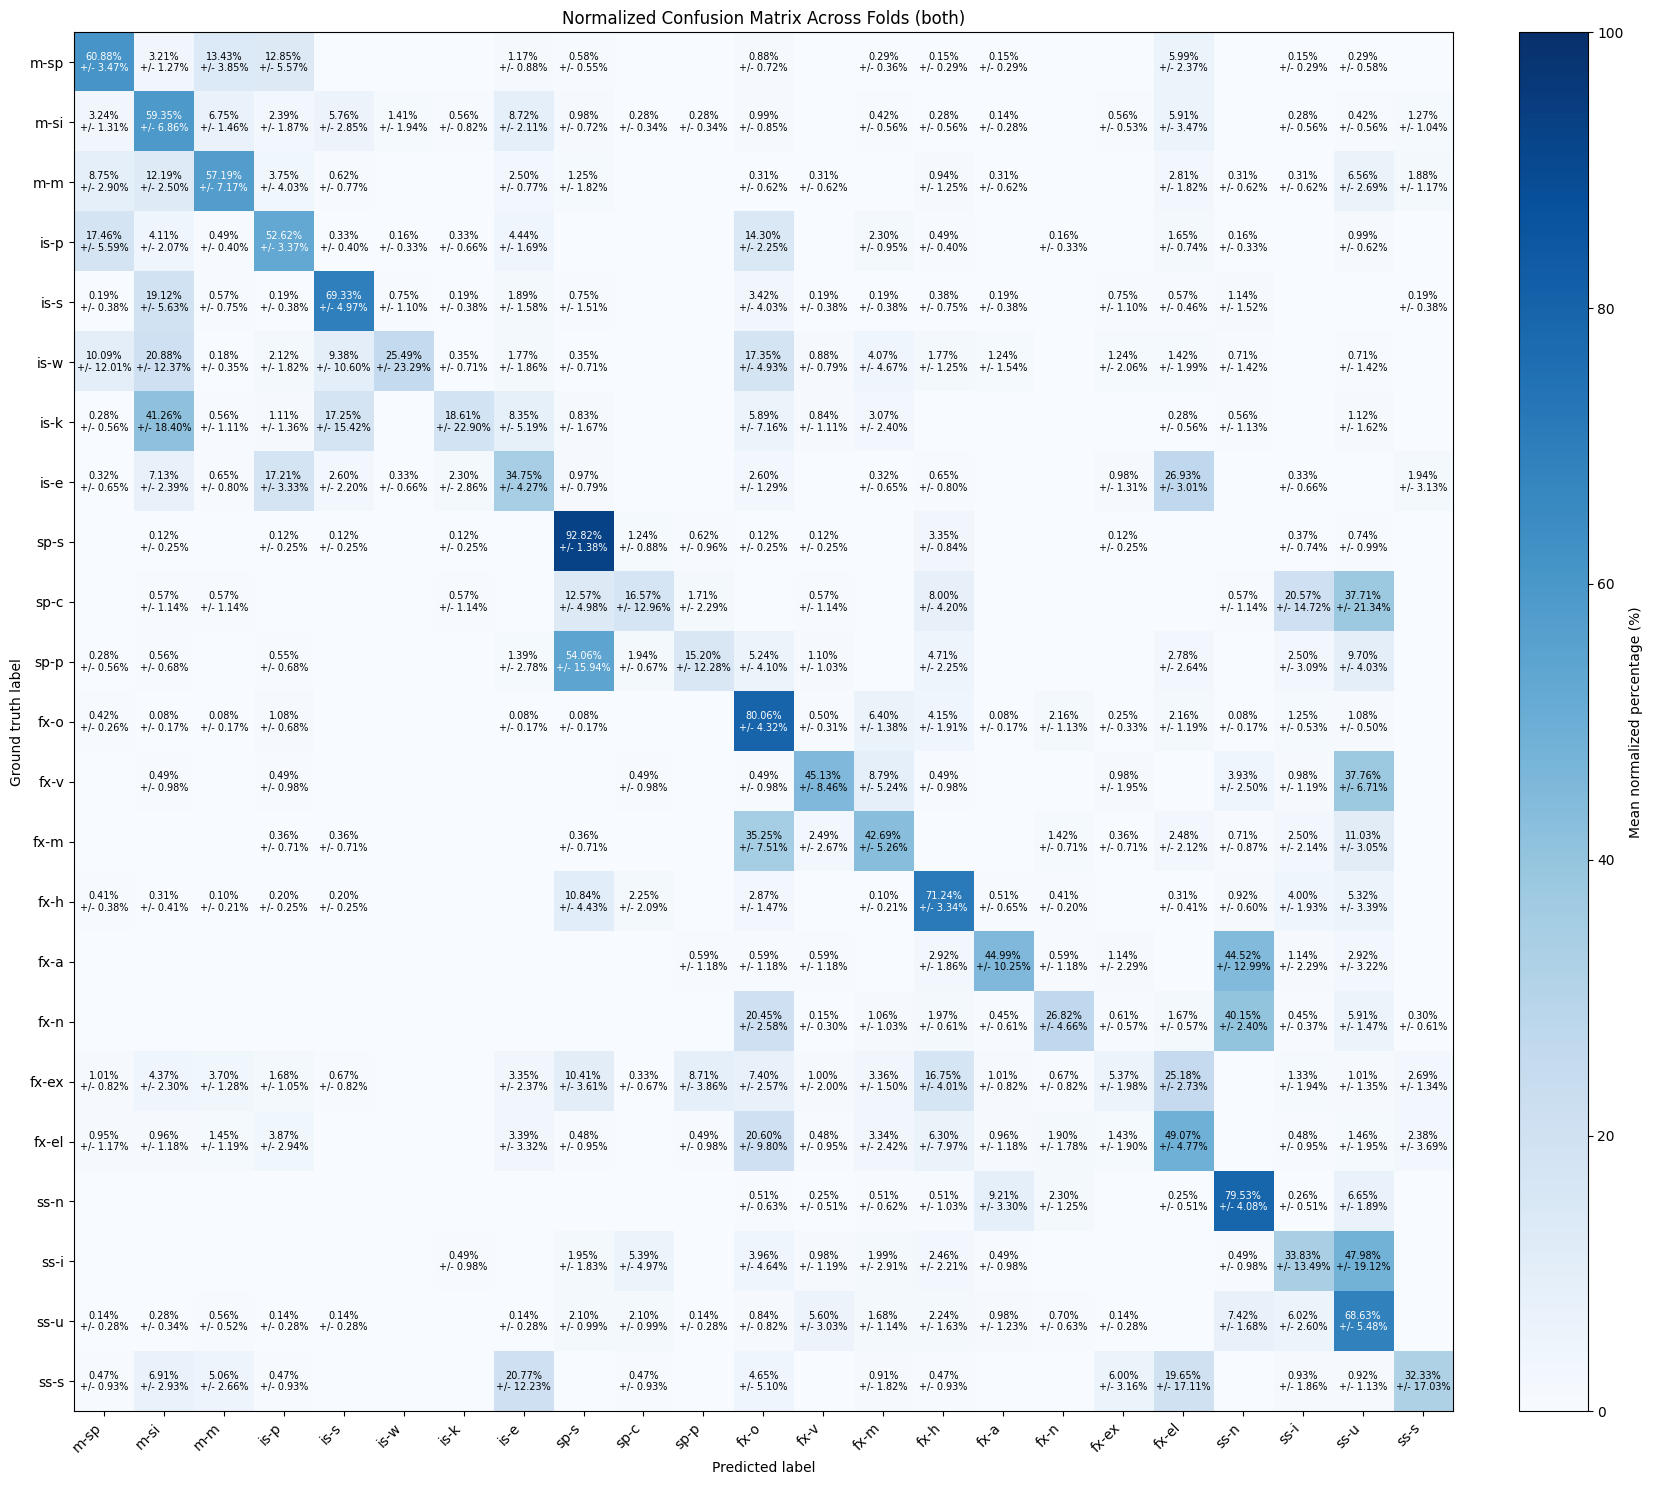

Saved: bsd35k_model_ouput\confusion_matrix_all_folds_normalized.png


In [19]:
import glob
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

OUTPUT_ROOT = 'bsd35k_model_ouput'
mode = MODE if 'MODE' in globals() else 'both'
prediction_paths = sorted(glob.glob(f'{OUTPUT_ROOT}/{mode}/fold_*/evaluation/predictions.csv'))

if not prediction_paths:
    raise FileNotFoundError(
        f'No prediction files found under {OUTPUT_ROOT}/{mode}/fold_*/evaluation/predictions.csv. '
        'Run the all-fold training/evaluation cell first.'
    )

if 'class_dict' not in globals():
    with open('data/class_dict_bsd35k_train_bsd10k_test.json', encoding='utf-8') as f:
        class_dict = json.load(f)

class_labels = [label for label, _ in sorted(class_dict.items(), key=lambda x: x[1])]
matrices = []
fold_accuracies = []
used_folds = []

for path in prediction_paths:
    fold_name = os.path.basename(os.path.dirname(os.path.dirname(path)))
    df = pd.read_csv(path)

    y_true = df['ground_truth'].astype(str)
    y_pred = df['prediction'].astype(str)

    cm = confusion_matrix(y_true, y_pred, labels=class_labels).astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sum, out=np.zeros_like(cm), where=row_sum != 0) * 100.0

    matrices.append(cm_norm)
    fold_accuracies.append((y_true == y_pred).mean() * 100.0)
    used_folds.append(fold_name)

matrices = np.stack(matrices, axis=0)
cm_mean = matrices.mean(axis=0)
cm_std = matrices.std(axis=0)
fold_accuracies = np.array(fold_accuracies)

print(f'Mode: {mode}')
print(f'Folds: {", ".join(used_folds)}')
print(f'Overall accuracy across folds: {fold_accuracies.mean():.2f}% +/- {fold_accuracies.std():.2f}%')
print('\nPer-class recall, diagonal of normalized confusion matrix:')
for label, mean, std in zip(class_labels, np.diag(cm_mean), np.diag(cm_std)):
    print(f'  {label:>8s}: {mean:.2f}% +/- {std:.2f}%')

fig_width = max(10, len(class_labels) * 0.75)
fig_height = max(8, len(class_labels) * 0.65)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

im = ax.imshow(cm_mean, cmap='Blues', vmin=0, vmax=100)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Mean normalized percentage (%)')

ax.set_title(f'Normalized Confusion Matrix Across Folds ({mode})')
ax.set_xlabel('Predicted label')
ax.set_ylabel('Ground truth label')
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.set_yticklabels(class_labels)

threshold = cm_mean.max() * 0.55 if cm_mean.size else 50
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        value = cm_mean[i, j]
        spread = cm_std[i, j]
        if value >= 0.01 or spread >= 0.01:
            color = 'white' if value > threshold else 'black'
            ax.text(
                j, i,
                f'{value:.2f}%\n+/- {spread:.2f}%',
                ha='center', va='center',
                color=color,
                fontsize=7,
            )

ax.set_ylim(len(class_labels) - 0.5, -0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'confusion_matrix_all_folds_normalized.png'), dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', os.path.join(OUTPUT_ROOT, 'confusion_matrix_all_folds_normalized.png'))



